# HeatMap Hackathon — Referral Network Gaps (NIRD 20230130)
# From Trauma to Burn Care care.

# Burn Referral Gaps in U.S. Trauma Hospitals

## Problem
Burn patients need rapid access to definitive specialty care, but trauma entry points do not always have burn capability.

## Why this matters
This capability mismatch may create referral friction, transfer delay, and uneven access to specialized burn care.

## Project goal
Identify trauma-capable hospitals that lack burn capability, summarize where these referral gaps are concentrated, separate adult and pediatric mismatches, and rank hospitals with the greatest likely burden.

In [3]:
# =========================================================
# 1. Imports
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Optional: make tables easier to read
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

In [4]:
# =========================================================
# 2. Load the Excel file
# =========================================================
file_path = Path("NIRD 20230130 Database_Hackathon.xlsx")
sheet_name = "Data Table NIRD 20230130"

df = pd.read_excel(file_path, sheet_name=sheet_name)

print("Shape:", df.shape)
df.head()

Shape: (635, 23)


,STATE_FULL,STATE,COUNTY,ADDRESS,CITY,ZIP_CODE,AHA_ID,HOSPITAL_NAME,TOTAL_BEDS,BURN_BEDS,TRAUMA_ADULT,TRAUMA_PEDS,BURN_ADULT,BURN_PEDS,ACS_VERIFIED,ADULT_TRAUMA_L1,ADULT_TRAUMA_L2,PEDS_TRAUMA_L1,PEDS_TRAUMA_L2,ABA_VERIFIED,TC_STATE_DESIGNATED,BC_STATE_DESIGNATED,PHONE
0,Alaska,AK,Anchorage,4315 Diplomacy Dr,Anchorage,99508,6940010.0,Alaska Native Medical Center,173,NaN,1.0,1.0,NaN,NaN,Yes,NaN,1.0,NaN,1.0,NaN,Yes,NaN,(907) 563-2662
1,Alaska,AK,Anchorage,3200 Providence Dr,Anchorage,99508,6940020.0,Providence Alaska Medical Center/Children's Ho...,401,NaN,1.0,1.0,NaN,NaN,Yes,NaN,1.0,NaN,1.0,NaN,Yes,NaN,(907) 562-2211
2,Alabama,AL,Houston,1108 Ross Clark Cir,Dothan,36301,6530373.0,Southeast Alabama Medical Center,387,NaN,1.0,NaN,NaN,NaN,No,NaN,1.0,NaN,NaN,NaN,Yes,NaN,(334) 793-8111
3,Alabama,AL,Jefferson,619 19th St S,Birmingham,35233,6530304.0,University of Alabama at Birmingham Hospital (...,1157,28.0,1.0,NaN,1.0,NaN,Yes,1.0,NaN,NaN,NaN,No,Yes,No,(205) 934-3411
4,Alabama,AL,Jefferson,1600 7th Ave South,Birmingham,35233,6530170.0,Children's of Alabama (Children's of Alabama B...,351,6.0,NaN,1.0,NaN,1.0,No,NaN,NaN,1.0,NaN,No,Yes,No,(205) 638-9100


In [5]:
# =========================================================
# 3. Inspect columns
# =========================================================
print(df.columns.tolist())

['STATE_FULL', 'STATE', 'COUNTY', 'ADDRESS', 'CITY', 'ZIP_CODE', 'AHA_ID', 'HOSPITAL_NAME', 'TOTAL_BEDS', 'BURN_BEDS', 'TRAUMA_ADULT', 'TRAUMA_PEDS', 'BURN_ADULT', 'BURN_PEDS', 'ACS_VERIFIED', 'ADULT_TRAUMA_L1', 'ADULT_TRAUMA_L2', 'PEDS_TRAUMA_L1', 'PEDS_TRAUMA_L2', 'ABA_VERIFIED', 'TC_STATE_DESIGNATED', 'BC_STATE_DESIGNATED', 'PHONE']


In [6]:
# =========================================================
# 4. Select needed columns
# =========================================================
needed_cols = [
    "HOSPITAL_NAME",
    "CITY",
    "STATE",
    "STATE_FULL",
    "TRAUMA_ADULT",
    "TRAUMA_PEDS",
    "BURN_ADULT",
    "BURN_PEDS"
]

data = df[needed_cols].copy()
data.head()

,HOSPITAL_NAME,CITY,STATE,STATE_FULL,TRAUMA_ADULT,TRAUMA_PEDS,BURN_ADULT,BURN_PEDS
0,Alaska Native Medical Center,Anchorage,AK,Alaska,1.0,1.0,NaN,NaN
1,Providence Alaska Medical Center/Children's Ho...,Anchorage,AK,Alaska,1.0,1.0,NaN,NaN
2,Southeast Alabama Medical Center,Dothan,AL,Alabama,1.0,NaN,NaN,NaN
3,University of Alabama at Birmingham Hospital (...,Birmingham,AL,Alabama,1.0,NaN,1.0,NaN
4,Children's of Alabama (Children's of Alabama B...,Birmingham,AL,Alabama,NaN,1.0,NaN,1.0


## Method
We identify trauma hospitals, then remove hospitals with burn capability.

In this dataset, capability is recorded as `1` when present. Missing values indicate absence, so we convert missing values to `0`.

In [7]:
# =========================================================
# 5. Clean capability columns
# =========================================================
capability_cols = ["TRAUMA_ADULT", "TRAUMA_PEDS", "BURN_ADULT", "BURN_PEDS"]

for col in capability_cols:
    data[col] = data[col].fillna(0)

# Ensure numeric
data[capability_cols] = data[capability_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)

data.head()

,HOSPITAL_NAME,CITY,STATE,STATE_FULL,TRAUMA_ADULT,TRAUMA_PEDS,BURN_ADULT,BURN_PEDS
0,Alaska Native Medical Center,Anchorage,AK,Alaska,1,1,0,0
1,Providence Alaska Medical Center/Children's Ho...,Anchorage,AK,Alaska,1,1,0,0
2,Southeast Alabama Medical Center,Dothan,AL,Alabama,1,0,0,0
3,University of Alabama at Birmingham Hospital (...,Birmingham,AL,Alabama,1,0,1,0
4,Children's of Alabama (Children's of Alabama B...,Birmingham,AL,Alabama,0,1,0,1


In [8]:
# =========================================================
# 6. Identify trauma-capable hospitals
# =========================================================
trauma_df = data[
    (data["TRAUMA_ADULT"] == 1) | (data["TRAUMA_PEDS"] == 1)
].copy()

print("Total trauma-capable hospitals:", trauma_df.shape[0])
trauma_df.head()

Total trauma-capable hospitals: 616


,HOSPITAL_NAME,CITY,STATE,STATE_FULL,TRAUMA_ADULT,TRAUMA_PEDS,BURN_ADULT,BURN_PEDS
0,Alaska Native Medical Center,Anchorage,AK,Alaska,1,1,0,0
1,Providence Alaska Medical Center/Children's Ho...,Anchorage,AK,Alaska,1,1,0,0
2,Southeast Alabama Medical Center,Dothan,AL,Alabama,1,0,0,0
3,University of Alabama at Birmingham Hospital (...,Birmingham,AL,Alabama,1,0,1,0
4,Children's of Alabama (Children's of Alabama B...,Birmingham,AL,Alabama,0,1,0,1


This output shows hospitals that have either adult or pediatric trauma capability. In total, 616 hospitals in the dataset can serve as trauma entry points for patients needing urgent care.

## Referral-gap definition
A referral-gap hospital is any hospital with adult or pediatric trauma capability but no adult or pediatric burn capability.

In [9]:
# =========================================================
# 7. Identify trauma hospitals without burn capability
# =========================================================
gap_df = trauma_df[
    (trauma_df["BURN_ADULT"] == 0) & (trauma_df["BURN_PEDS"] == 0)
].copy()

print("Referral-gap hospitals:", gap_df.shape[0])
gap_df.head()

Referral-gap hospitals: 498


,HOSPITAL_NAME,CITY,STATE,STATE_FULL,TRAUMA_ADULT,TRAUMA_PEDS,BURN_ADULT,BURN_PEDS
0,Alaska Native Medical Center,Anchorage,AK,Alaska,1,1,0,0
1,Providence Alaska Medical Center/Children's Ho...,Anchorage,AK,Alaska,1,1,0,0
2,Southeast Alabama Medical Center,Dothan,AL,Alabama,1,0,0,0
5,Huntsville Hospital,Huntsville,AL,Alabama,1,0,0,0
7,Baptist Medical Center South,Montgomery,AL,Alabama,1,0,0,0


This table shows trauma-capable hospitals that have no adult or pediatric burn capability. These 498 hospitals represent possible referral-gap locations where burn patients may need transfer to another facility for definitive burn care.

## Results: National counts
We first summarize the national scale of the referral-gap problem.

In [10]:
# =========================================================
# 8. National summary metrics
# =========================================================
total_hospitals = data.shape[0]
total_trauma = trauma_df.shape[0]
total_burn = data[(data["BURN_ADULT"] == 1) | (data["BURN_PEDS"] == 1)].shape[0]
total_gap = gap_df.shape[0]
pct_gap_of_trauma = round((total_gap / total_trauma) * 100, 1) if total_trauma > 0 else 0

summary = pd.DataFrame({
    "Metric": [
        "Total hospitals",
        "Total trauma-capable hospitals",
        "Total burn-capable hospitals",
        "Referral-gap hospitals",
        "% of trauma hospitals lacking burn capability"
    ],
    "Value": [
        total_hospitals,
        total_trauma,
        total_burn,
        total_gap,
        pct_gap_of_trauma
    ]
})

summary

,Metric,Value
0,Total hospitals,635.0
1,Total trauma-capable hospitals,616.0
2,Total burn-capable hospitals,136.0
3,Referral-gap hospitals,498.0
4,% of trauma hospitals lacking burn capability,80.8


 table summarizes the national scale of the issue. Out of 616 trauma-capable hospitals, 498 lack burn capability, meaning about 80.8% of trauma hospitals may need to refer burn patients elsewhere for specialized treatment.To calculate this i used this fomula Referal gap percent = referal gap hospitals/ total trauma capable hospital * 100 

## Results: State counts
We count referral-gap hospitals by state to identify where they are most concentrated.

In [11]:
# =========================================================
# 9. Count referral-gap hospitals by state
# =========================================================
state_counts = (
    gap_df.groupby(["STATE_FULL", "STATE"])
    .size()
    .reset_index(name="referral_gap_hospitals")
    .sort_values("referral_gap_hospitals", ascending=False)
)

state_counts.head(15)

,STATE_FULL,STATE,referral_gap_hospitals
13,Illinois,IL,52
4,California,CA,49
41,Texas,TX,38
22,Michigan,MI,30
9,Florida,FL,30
37,Pennsylvania,PA,29
31,New York,NY,26
34,Ohio,OH,18
5,Colorado,CO,15
10,Georgia,GA,13


This table ranks states by the number of trauma hospitals without burn capability. Illinois, California, and Texas appear near the top, meaning they have the largest raw number of potential referral-gap hospitals.

Important note:
High counts do not automatically mean worse access overall, because larger states often have more hospitals.

## Results: Normalized state rates
Raw counts can be influenced by state size. To account for this, we compute the percentage of trauma hospitals in each state that lack burn capability.

In [12]:
# =========================================================
# 10. Compute state trauma totals and normalized referral-gap rates
# =========================================================
state_trauma_counts = (
    trauma_df.groupby(["STATE_FULL", "STATE"])
    .size()
    .reset_index(name="trauma_hospitals")
)

state_summary = state_counts.merge(
    state_trauma_counts,
    on=["STATE_FULL", "STATE"],
    how="left"
)

state_summary["referral_gap_rate"] = (
    state_summary["referral_gap_hospitals"] / state_summary["trauma_hospitals"]
) * 100

state_summary = state_summary.sort_values("referral_gap_rate", ascending=False)
state_summary.head(15)

,STATE_FULL,STATE,referral_gap_hospitals,trauma_hospitals,referral_gap_rate
23,North Dakota,ND,6,6,100.000000
43,Delaware,DE,2,2,100.000000
42,Alaska,AK,2,2,100.000000
40,Hawaii,HI,2,2,100.000000
35,South Dakota,SD,3,3,100.000000
33,Mississippi,MS,4,4,100.000000
30,Montana,MT,4,4,100.000000
29,New Hampshire,NH,4,4,100.000000
24,Nebraska,NE,6,6,100.000000
14,New Jersey,NJ,10,10,100.000000


These numbers shows percentage wise - these hospitals have the least amount of burn care centers. These percentages show where burn capability is least available relative to trauma capacity, not just where the raw number of hospitals is highest.


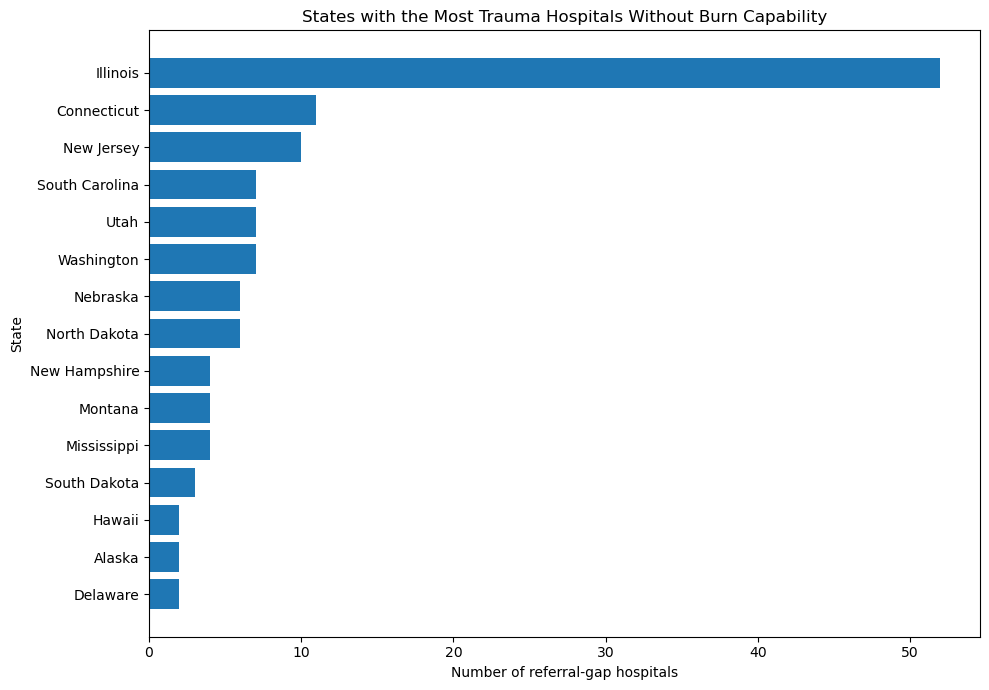

In [13]:
# =========================================================
# 11. Bar chart: states with most Trauma hospital without Burn Capability
# =========================================================
top_n = 15
plot_df = state_summary.head(top_n).sort_values("referral_gap_hospitals", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(plot_df["STATE_FULL"], plot_df["referral_gap_hospitals"])
plt.xlabel("Number of referral-gap hospitals")
plt.ylabel("State")
plt.title("States with the Most Trauma Hospitals Without Burn Capability")
plt.tight_layout()
plt.show()

States at the top of this chart may have more burn referral pressure simply because they have many trauma centers without burn services.

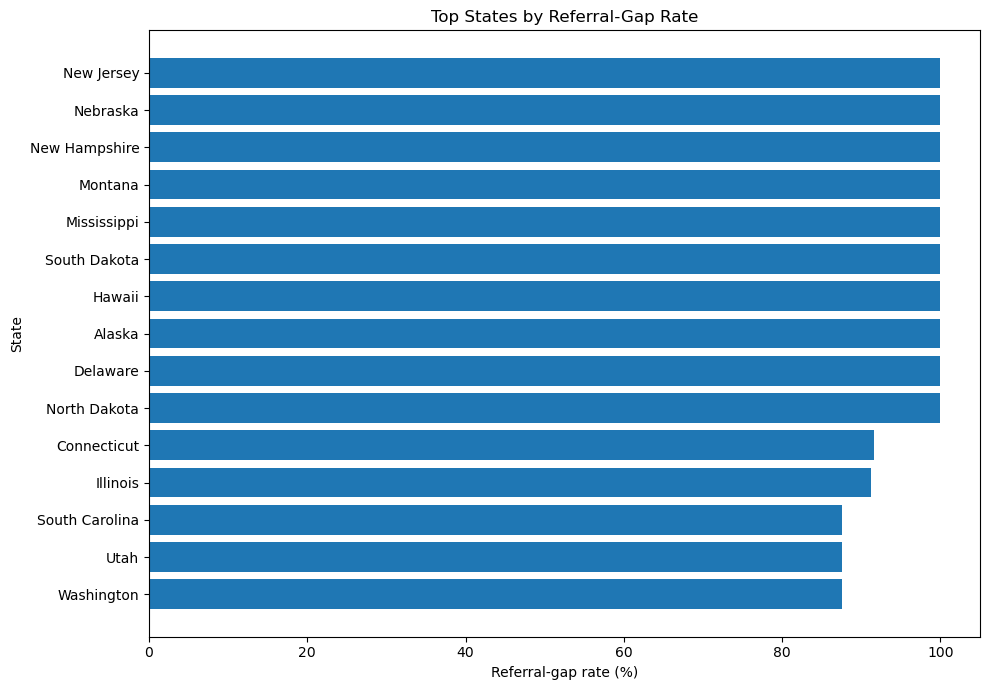

In [17]:
# =========================================================
# 12. Bar chart: states with highest referral-gap rates
# =========================================================
top_n = 15
plot_rate_df = state_summary.sort_values("referral_gap_rate", ascending=False).head(top_n)
plot_rate_df = plot_rate_df.sort_values("referral_gap_rate", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(plot_rate_df["STATE_FULL"], plot_rate_df["referral_gap_rate"])
plt.xlabel("Referral-gap rate (%)")
plt.ylabel("State")
plt.title("Top States by Referral-Gap Rate")
plt.tight_layout()
plt.show()

## Results: Adult and pediatric gaps
We separate adult and pediatric mismatch patterns because burn access may differ across these populations.

In [18]:
# =========================================================
# 13. Adult and pediatric mismatch categories
# =========================================================
adult_gap_df = data[
    (data["TRAUMA_ADULT"] == 1) & (data["BURN_ADULT"] == 0)
].copy()

peds_gap_df = data[
    (data["TRAUMA_PEDS"] == 1) & (data["BURN_PEDS"] == 0)
].copy()

dual_trauma_no_burn_df = data[
    ((data["TRAUMA_ADULT"] == 1) | (data["TRAUMA_PEDS"] == 1)) &
    (data["BURN_ADULT"] == 0) &
    (data["BURN_PEDS"] == 0)
].copy()

mixed_mismatch_df = data[
    (
        ((data["TRAUMA_ADULT"] == 1) & (data["BURN_ADULT"] == 0) & (data["BURN_PEDS"] == 1)) |
        ((data["TRAUMA_PEDS"] == 1) & (data["BURN_PEDS"] == 0) & (data["BURN_ADULT"] == 1))
    )
].copy()

gap_summary = pd.DataFrame({
    "Category": [
        "Adult trauma without adult burn",
        "Pediatric trauma without pediatric burn",
        "Any trauma with no burn capability",
        "Mixed mismatch hospitals"
    ],
    "Count": [
        adult_gap_df.shape[0],
        peds_gap_df.shape[0],
        dual_trauma_no_burn_df.shape[0],
        mixed_mismatch_df.shape[0]
    ]
})

gap_summary

,Category,Count
0,Adult trauma without adult burn,462
1,Pediatric trauma without pediatric burn,100
2,Any trauma with no burn capability,498
3,Mixed mismatch hospitals,10


This comparison shows that adult trauma-burn mismatches are far more common than pediatric ones. It suggests that burn referral gaps are widespread, especially for hospitals serving adult trauma patients.

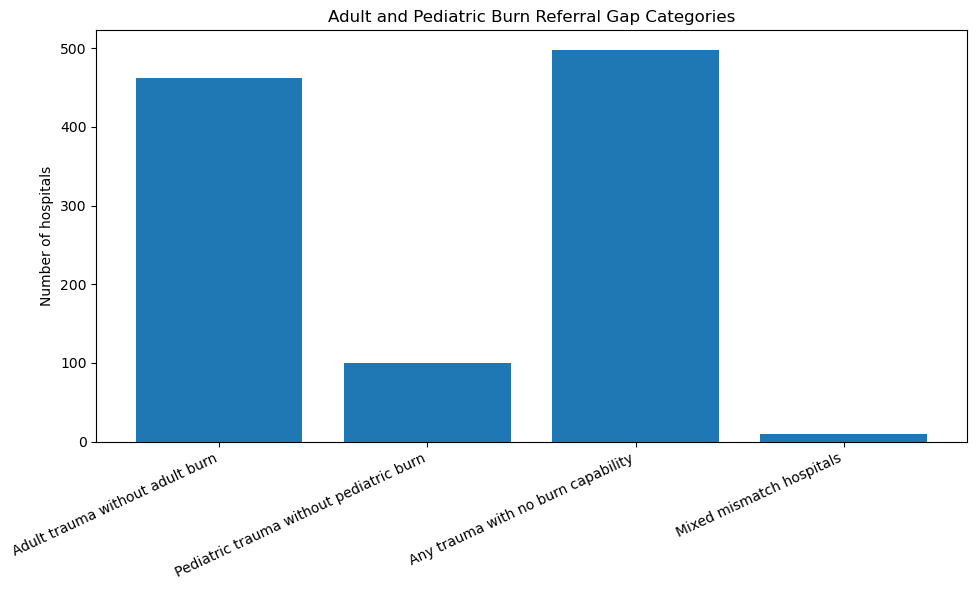

In [19]:
# =========================================================
# 14. Plot adult vs pediatric gap counts
# =========================================================
plt.figure(figsize=(10, 6))
plt.bar(gap_summary["Category"], gap_summary["Count"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Number of hospitals")
plt.title("Adult and Pediatric Burn Referral Gap Categories")
plt.tight_layout()
plt.show()

In [20]:
# =========================================================
# 15. Build a first-pass priority score
# =========================================================
priority_df = gap_df.copy()

priority_df["adult_gap_flag"] = np.where(
    (priority_df["TRAUMA_ADULT"] == 1) & (priority_df["BURN_ADULT"] == 0), 1, 0
)

priority_df["peds_gap_flag"] = np.where(
    (priority_df["TRAUMA_PEDS"] == 1) & (priority_df["BURN_PEDS"] == 0), 1, 0
)

priority_df["dual_trauma_flag"] = np.where(
    (priority_df["TRAUMA_ADULT"] == 1) & (priority_df["TRAUMA_PEDS"] == 1), 1, 0
)

priority_df["priority_score"] = (
    priority_df["adult_gap_flag"] * 2 +
    priority_df["peds_gap_flag"] * 2 +
    priority_df["dual_trauma_flag"] * 1
)

priority_ranked = priority_df.sort_values(
    ["priority_score", "STATE_FULL", "CITY", "HOSPITAL_NAME"],
    ascending=[False, True, True, True]
)

priority_ranked[
    ["HOSPITAL_NAME", "CITY", "STATE_FULL", "TRAUMA_ADULT", "TRAUMA_PEDS", "BURN_ADULT", "BURN_PEDS", "priority_score"]
].head(25)

,HOSPITAL_NAME,CITY,STATE_FULL,TRAUMA_ADULT,TRAUMA_PEDS,BURN_ADULT,BURN_PEDS,priority_score
0,Alaska Native Medical Center,Anchorage,Alaska,1,1,0,0,5
1,Providence Alaska Medical Center/Children's Ho...,Anchorage,Alaska,1,1,0,0,5
12,Banner Desert Medical Center/Banner Children's...,Mesa,Arizona,1,1,0,0,5
68,Loma Linda University Medical Center/Loma Lind...,Loma Linda,California,1,1,0,0,5
54,Providence Mission Hospital,Mission Viejo,California,1,1,0,0,5
78,Stanford Health Care/Lucile Packard Children's...,Palo Alto,California,1,1,0,0,5
98,Denver Health Medical Center,Denver,Colorado,1,1,0,0,5
119,Yale-New Haven Hospital,New Haven,Connecticut,1,1,0,0,5
130,Memorial Regional Hospital/Joe DiMaggio Childr...,Hollywood,Florida,1,1,0,0,5
137,Ascension Sacred Heart Pensacola,Pensacola,Florida,1,1,0,0,5


In [21]:
# =========================================================
# 16. Optional: summarize priority hospitals by state
# =========================================================
priority_state_summary = (
    priority_ranked.groupby(["STATE_FULL", "STATE"])["priority_score"]
    .agg(["count", "mean", "max"])
    .reset_index()
    .rename(columns={
        "count": "gap_hospital_count",
        "mean": "avg_priority_score",
        "max": "max_priority_score"
    })
    .sort_values(["avg_priority_score", "gap_hospital_count"], ascending=[False, False])
)

priority_state_summary.head(15)

,STATE_FULL,STATE,gap_hospital_count,avg_priority_score,max_priority_score
1,Alaska,AK,2,5.000000,5
35,Oklahoma,OK,1,5.000000,5
15,Iowa,IA,3,4.000000,5
38,South Carolina,SC,7,3.285714,5
30,New Jersey,NJ,10,3.200000,5
14,Indiana,IN,5,3.200000,5
21,Massachusetts,MA,8,3.125000,5
16,Kansas,KS,3,3.000000,5
17,Kentucky,KY,3,3.000000,5
39,South Dakota,SD,3,3.000000,5


## Summary
The analysis shows that burn capability is much less common than trauma capability across the dataset. States such as Illinois, California, and Texas have the largest numbers of referral-gap hospitals, while several smaller states have very high referral-gap rates when adjusted for trauma hospital totals.


## Recommendations
give me recommendations 

Hospitals and health systems should strengthen referral pathways between trauma centers and burn-capable hospitals, especially in states with high referral-gap counts or rates. Future work could add distance, transport time, burn bed counts, and regional population data to better identify the most urgent access gaps.